# Narnia-Large: Opus Agency NER Analysis

Analysis of Claude Opus predictions across all 17 chapters of *The Lion, the Witch and the Wardrobe*.
Source: `results/opus_all_chapters.csv` (concatenated from per-chapter prediction files).

In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict

df = pd.read_csv('results/opus_all_chapters.csv')

def parse_entities(s):
    if pd.isna(s) or s == '[]':
        return []
    try:
        return json.loads(s)
    except:
        return []

df['parsed'] = df['entities'].apply(parse_entities)
df['n_entities'] = df['parsed'].apply(len)
all_ents = [e for row in df['parsed'] for e in row]

print(f"Total sentences:          {len(df)}")
print(f"Sentences with entities:  {df['parsed'].apply(bool).sum()} ({df['parsed'].apply(bool).mean()*100:.1f}%)")
print(f"Total entity mentions:    {len(all_ents)}")

Total sentences:          2404
Sentences with entities:  1592 (66.2%)
Total entity mentions:    2361


## 1. Label Distribution

Opus uses six agency labels. Nearly 60% of mentions are active (speaker, performer, or thought-holder),
reflecting the model's tendency to assign agency where syntactic cues are present.
`MENTIONED_ONLY` captures referential mentions with no clausal action — typically pronouns in
subordinate clauses or character names in exposition. `ADDRESSED` covers direct address (vocatives
and dialogue targets), which is distinct from active participation.

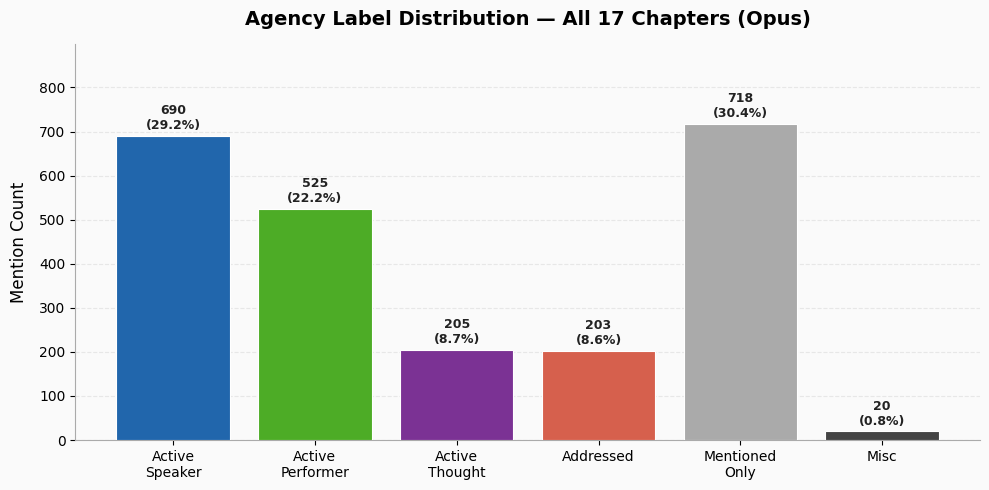

In [2]:
label_counts = Counter(e['label'] for e in all_ents)
labels_ordered = ['ACTIVE_SPEAKER', 'ACTIVE_PERFORMER', 'ACTIVE_THOUGHT', 'ADDRESSED', 'MENTIONED_ONLY', 'MISCELLANEOUS']
counts = [label_counts.get(l, 0) for l in labels_ordered]
total = sum(counts)

colors = ['#2166AC', '#4DAC26', '#7B3294', '#D6604D', '#AAAAAA', '#444444']
short_labels = ['Active\nSpeaker', 'Active\nPerformer', 'Active\nThought', 'Addressed', 'Mentioned\nOnly', 'Misc']

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.bar(short_labels, counts, color=colors, edgecolor='white', linewidth=0.8, zorder=3)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 8,
            f'{count}\n({count/total*100:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222222')

ax.set_ylabel('Mention Count', fontsize=12, labelpad=8)
ax.set_title('Agency Label Distribution — All 17 Chapters (Opus)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylim(0, max(counts) * 1.25)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

plt.tight_layout()
plt.savefig('results/label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Top Characters by Total Mentions

Edmund and Lucy lead in raw mention count (≈411 each), reflecting their dual roles as the primary
POV characters: Lucy discovers Narnia, Edmund's betrayal drives the plot. Aslan and Jadis are
nearly tied (320 vs. 310) as the antagonistic poles of the narrative. The Pevensie-heavy top 6
confirms the model correctly centers mentions on the child protagonists.

/var/folders/xb/b_n_1r5n1hj458lcndhx_7200000gn/T/ipykernel_5063/1696608330.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=10)


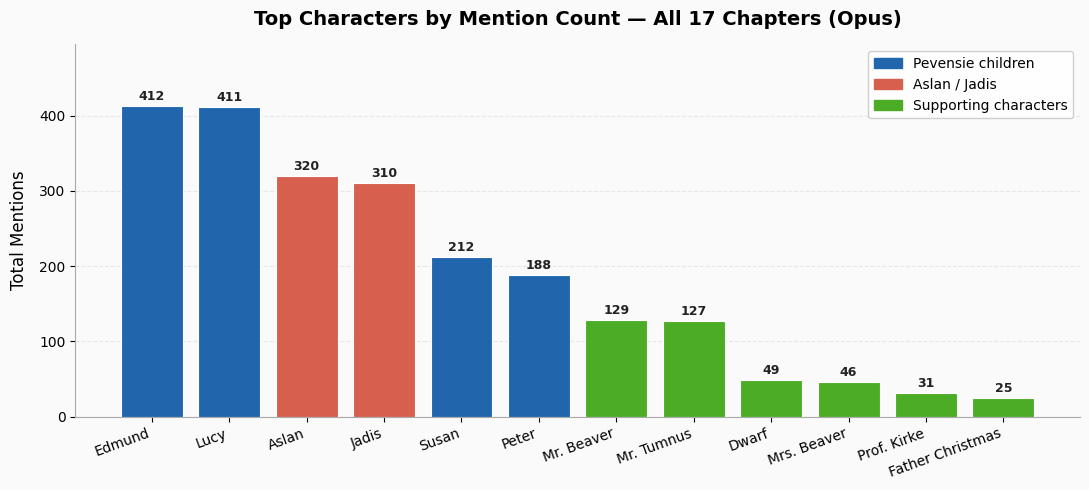

In [3]:
canon_counts = Counter(e['canonical'] for e in all_ents)
top_n = 12
top_chars = [(char, count) for char, count in canon_counts.most_common(top_n)
             if char != 'MISCELLANEOUS']

chars, counts = zip(*top_chars)
short_names = [c.replace(' Pevensie', '').replace('Professor Digory ', 'Prof. ') for c in chars]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bar_colors = ['#2166AC' if 'Pevensie' in c else
               '#D6604D' if c in ('Aslan', 'Jadis') else
               '#4DAC26' for c in chars]

bars = ax.bar(short_names, counts, color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, count + 4,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222222')

legend_handles = [
    mpatches.Patch(color='#2166AC', label='Pevensie children'),
    mpatches.Patch(color='#D6604D', label='Aslan / Jadis'),
    mpatches.Patch(color='#4DAC26', label='Supporting characters'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='upper right',
          frameon=True, framealpha=0.95, edgecolor='#CCCCCC')

ax.set_ylabel('Total Mentions', fontsize=12, labelpad=8)
ax.set_title('Top Characters by Mention Count — All 17 Chapters (Opus)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylim(0, max(counts) * 1.2)
ax.set_xticklabels(short_names, rotation=20, ha='right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

plt.tight_layout()
plt.savefig('results/top_characters.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Agency Breakdown per Character (Stacked Bar)

The stacked breakdown reveals *how* characters participate, not just how often they appear.
Susan leads in active agency ratio (78%), likely because she appears mainly in dialogue-heavy scenes
and is rarely the subject of expository narration alone. Edmund's comparatively low ratio (64%)
reflects his extended section as a passive/mentioned figure during his time with the White Witch.

Aslan and Jadis have the lowest active ratios (~39%) among the major characters — paradoxically,
the most powerful figures are talked *about* far more than they act within individual sentences.
This matches their narrative function as off-screen forces whose presence is felt through other
characters' reactions.

/var/folders/xb/b_n_1r5n1hj458lcndhx_7200000gn/T/ipykernel_5063/3781340713.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(short, rotation=22, ha='right', fontsize=10)


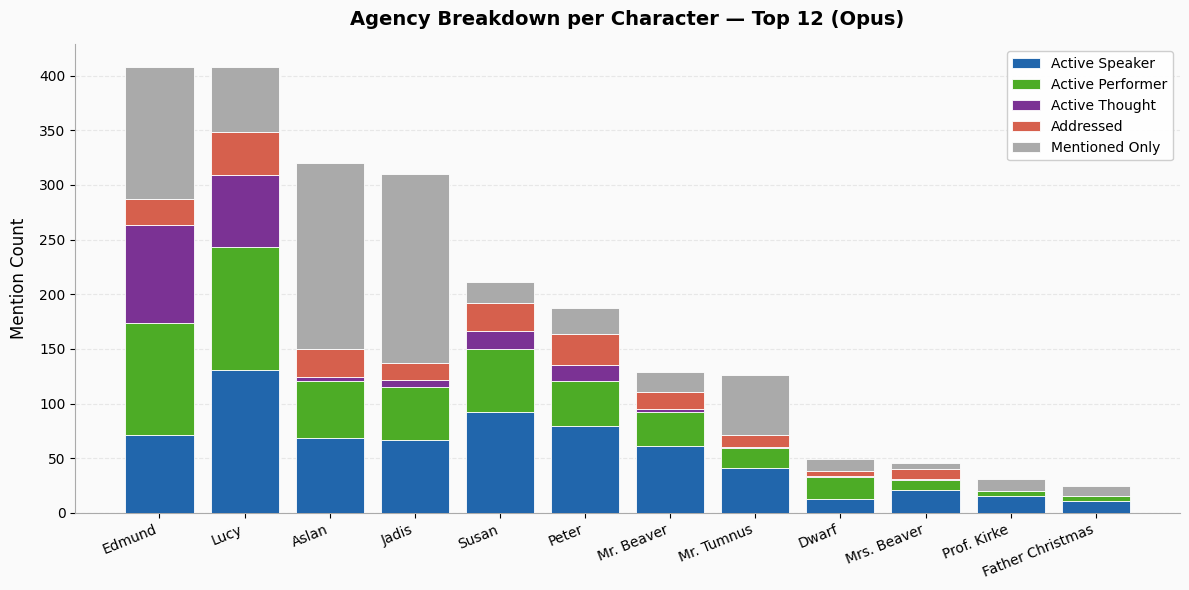

In [4]:
char_agency = defaultdict(Counter)
for e in all_ents:
    char_agency[e['canonical']][e['label']] += 1

focus_chars = [c for c, _ in canon_counts.most_common(12) if c != 'MISCELLANEOUS']
short = [c.replace(' Pevensie', '').replace('Professor Digory ', 'Prof. ') for c in focus_chars]

label_stack = ['ACTIVE_SPEAKER', 'ACTIVE_PERFORMER', 'ACTIVE_THOUGHT', 'ADDRESSED', 'MENTIONED_ONLY']
stack_colors = ['#2166AC', '#4DAC26', '#7B3294', '#D6604D', '#AAAAAA']
stack_labels = ['Active Speaker', 'Active Performer', 'Active Thought', 'Addressed', 'Mentioned Only']

data = np.array([[char_agency[c].get(l, 0) for c in focus_chars] for l in label_stack])

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bottoms = np.zeros(len(focus_chars))
for i, (layer, color, label) in enumerate(zip(data, stack_colors, stack_labels)):
    ax.bar(short, layer, bottom=bottoms, color=color, edgecolor='white',
           linewidth=0.6, label=label, zorder=3)
    bottoms += layer

ax.set_ylabel('Mention Count', fontsize=12, labelpad=8)
ax.set_title('Agency Breakdown per Character — Top 12 (Opus)', fontsize=14, fontweight='bold', pad=14)
ax.set_xticklabels(short, rotation=22, ha='right', fontsize=10)
ax.legend(fontsize=10, loc='upper right', frameon=True, framealpha=0.95, edgecolor='#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

plt.tight_layout()
plt.savefig('results/agency_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Active Agency Ratio per Character

Active agency = (ACTIVE_SPEAKER + ACTIVE_PERFORMER + ACTIVE_THOUGHT) / total mentions.
This normalizes for raw frequency and isolates *narrative role density*.

The Pevensie children cluster above 64%, with Susan and Lucy especially high. Supporting characters
like Mr. Beaver (73%) punch above their weight — most of his appearances are in action-dense scenes
(the beavers' dam, the journey to the Stone Table). Aslan and Jadis bottoming out at ~39% is the
most analytically interesting result: it suggests the model (and potentially the text itself) treats
them more as narrative *objects* than agents within individual sentences.

/var/folders/xb/b_n_1r5n1hj458lcndhx_7200000gn/T/ipykernel_5063/4074214992.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_short, rotation=20, ha='right', fontsize=10)


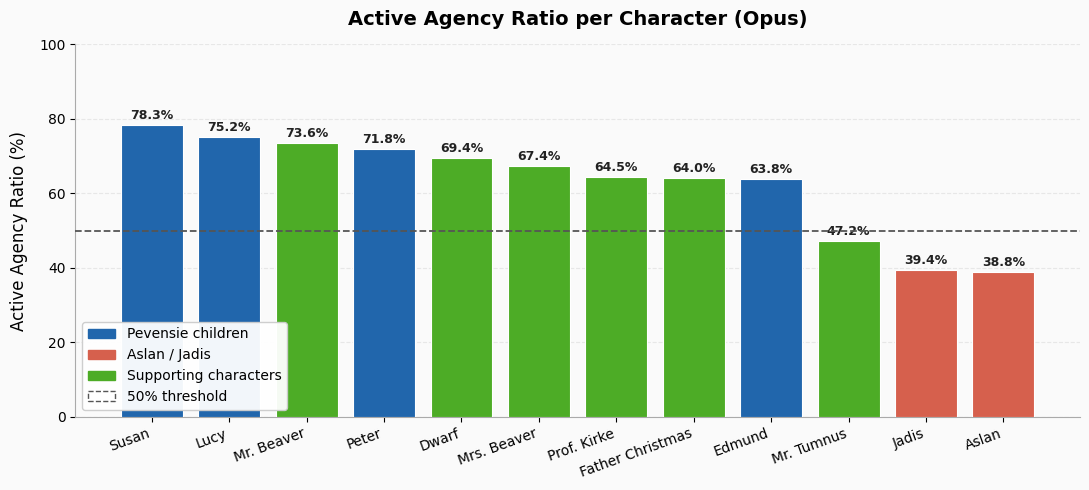

In [5]:
active_labels = {'ACTIVE_SPEAKER', 'ACTIVE_PERFORMER', 'ACTIVE_THOUGHT'}
ratios = []
for char in focus_chars:
    c = char_agency[char]
    total = sum(c.values())
    active = sum(c.get(l, 0) for l in active_labels)
    ratios.append(active / total * 100)

sorted_pairs = sorted(zip(ratios, short, focus_chars), reverse=True)
sorted_ratios, sorted_short, sorted_chars = zip(*sorted_pairs)

bar_colors = ['#2166AC' if 'Pevensie' in c else
               '#D6604D' if c in ('Aslan', 'Jadis') else
               '#4DAC26' for c in sorted_chars]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

bars = ax.bar(sorted_short, sorted_ratios, color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)
for bar, ratio in zip(bars, sorted_ratios):
    ax.text(bar.get_x() + bar.get_width() / 2, ratio + 0.8,
            f'{ratio:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#222222')

ax.axhline(y=50, color='#555555', linestyle='--', linewidth=1.3, zorder=4, label='50% threshold')

legend_handles = [
    mpatches.Patch(color='#2166AC', label='Pevensie children'),
    mpatches.Patch(color='#D6604D', label='Aslan / Jadis'),
    mpatches.Patch(color='#4DAC26', label='Supporting characters'),
    mpatches.Patch(facecolor='white', edgecolor='#555555', linestyle='--', label='50% threshold'),
]
ax.legend(handles=legend_handles, fontsize=10, loc='lower left',
          frameon=True, framealpha=0.95, edgecolor='#CCCCCC')

ax.set_ylabel('Active Agency Ratio (%)', fontsize=12, labelpad=8)
ax.set_title('Active Agency Ratio per Character (Opus)', fontsize=14, fontweight='bold', pad=14)
ax.set_ylim(0, 100)
ax.set_xticklabels(sorted_short, rotation=20, ha='right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

plt.tight_layout()
plt.savefig('results/active_agency_ratio.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Entity Density per Chapter

Entity density (mentions per sentence) tracks narrative intensity across the book's arc.
Peaks at chapters 8 and 15 (~1.3–1.4 mentions/sentence) correspond to the beavers' escape and
the battle/resurrection sequence — the most action-dense sections. Chapter 1 is notably sparse
(0.72/sentence) as it is primarily scene-setting with few named characters interacting.

The gradual rise from chapter 1 through the midpoint and the second surge toward chapter 15
mirrors the narrative structure of rising action → climax → falling action.

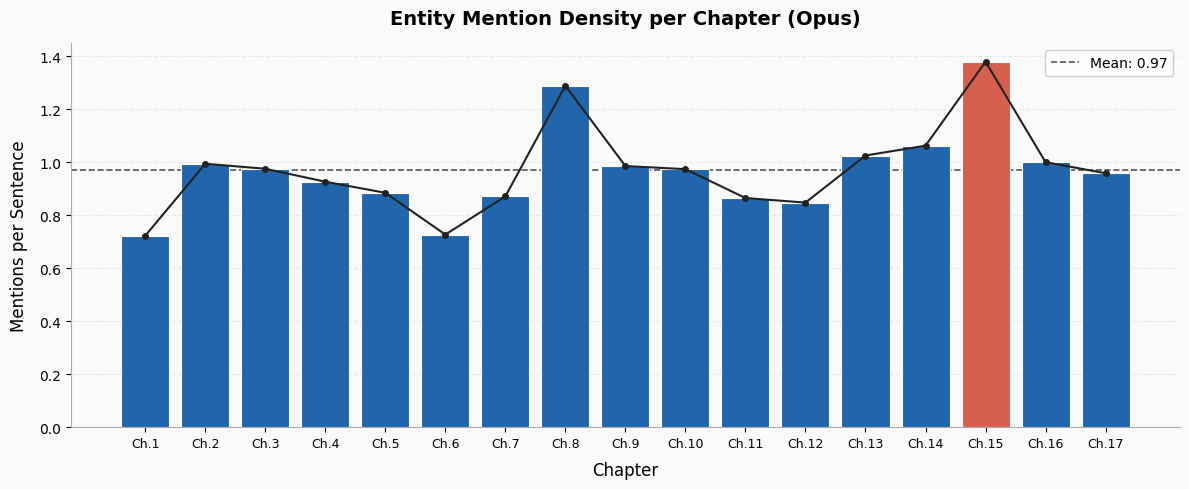

In [6]:
chapter_stats = df.groupby('chapter').agg(
    sentences=('sentence_id', 'count'),
    total_mentions=('n_entities', 'sum')
)
chapter_stats['density'] = chapter_stats['total_mentions'] / chapter_stats['sentences']
chapter_stats = chapter_stats.reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#FAFAFA')
ax1.set_facecolor('#FAFAFA')

x = chapter_stats['chapter']
bar_color = ['#D6604D' if d == chapter_stats['density'].max() else '#2166AC'
             for d in chapter_stats['density']]

ax1.bar(x, chapter_stats['density'], color=bar_color, edgecolor='white', linewidth=0.8, zorder=3)
ax1.plot(x, chapter_stats['density'], color='#222222', linewidth=1.5,
         marker='o', markersize=4, zorder=4)

ax1.set_xlabel('Chapter', fontsize=12, labelpad=8)
ax1.set_ylabel('Mentions per Sentence', fontsize=12, labelpad=8)
ax1.set_title('Entity Mention Density per Chapter (Opus)', fontsize=14, fontweight='bold', pad=14)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Ch.{i}' for i in x], fontsize=9)
ax1.axhline(chapter_stats['density'].mean(), color='#555555', linestyle='--',
            linewidth=1.2, label=f"Mean: {chapter_stats['density'].mean():.2f}")
ax1.legend(fontsize=10, frameon=True, framealpha=0.95, edgecolor='#CCCCCC')
ax1.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax1.set_axisbelow(True)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['left'].set_color('#AAAAAA')
ax1.spines['bottom'].set_color('#AAAAAA')

plt.tight_layout()
plt.savefig('results/chapter_density.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Character Arc: Edmund and Lucy Across Chapters

Tracking Edmund and Lucy's per-chapter mention counts shows the narrative's shifting focus.
Lucy dominates early chapters (her Narnia discovery). Edmund's mentions peak mid-book during
his betrayal arc and then the two reconverge toward the climax, where all four children are
present. This cross-chapter view also surfaces how well the model maintains canonical name
resolution (e.g., mapping 'he', 'the boy' → Edmund Pevensie) consistently across long contexts.

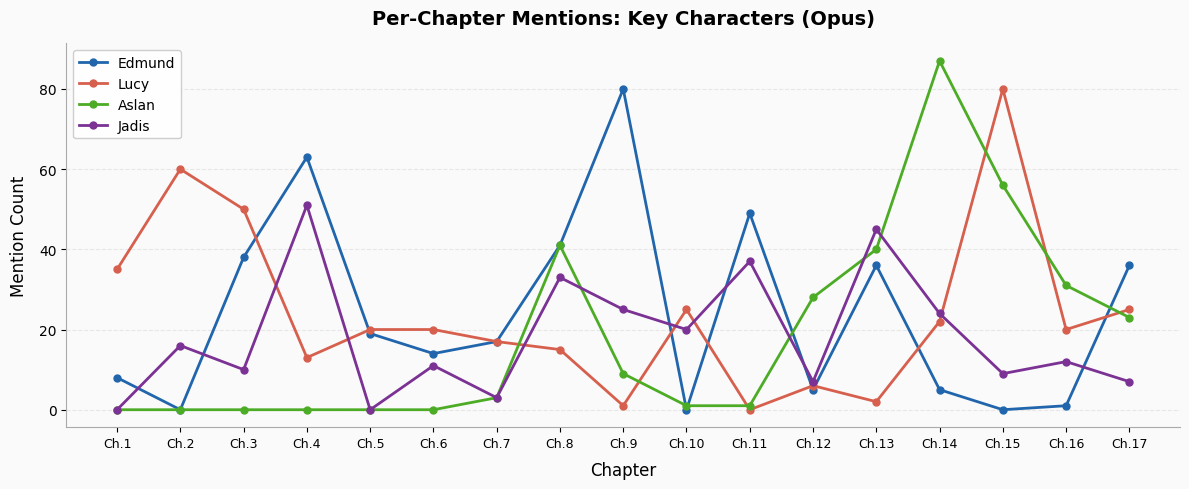

In [7]:
rows = []
for _, row in df.iterrows():
    for e in row['parsed']:
        rows.append({'chapter': row['chapter'], 'canonical': e['canonical'], 'label': e['label']})
ent_df = pd.DataFrame(rows)

focus = ['Edmund Pevensie', 'Lucy Pevensie', 'Aslan', 'Jadis']
colors_map = {
    'Edmund Pevensie': '#2166AC',
    'Lucy Pevensie':   '#D6604D',
    'Aslan':           '#4DAC26',
    'Jadis':           '#7B3294',
}

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

chapters = sorted(df['chapter'].unique())
for char in focus:
    counts_per_ch = (
        ent_df[ent_df['canonical'] == char]
        .groupby('chapter')
        .size()
        .reindex(chapters, fill_value=0)
    )
    short_name = char.replace(' Pevensie', '')
    ax.plot(chapters, counts_per_ch.values, marker='o', markersize=5,
            linewidth=2, color=colors_map[char], label=short_name)

ax.set_xlabel('Chapter', fontsize=12, labelpad=8)
ax.set_ylabel('Mention Count', fontsize=12, labelpad=8)
ax.set_title('Per-Chapter Mentions: Key Characters (Opus)', fontsize=14, fontweight='bold', pad=14)
ax.set_xticks(chapters)
ax.set_xticklabels([f'Ch.{i}' for i in chapters], fontsize=9)
ax.legend(fontsize=10, loc='upper left', frameon=True, framealpha=0.95, edgecolor='#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#AAAAAA')
ax.spines['bottom'].set_color('#AAAAAA')

plt.tight_layout()
plt.savefig('results/character_arcs.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary of Qualitative Insights

**1. Active label dominance.** ~60% of all mentions are active (speaker/performer/thought),
suggesting Opus leans toward assigning agency wherever syntactic structure permits. Whether this
reflects the text's actual distribution or a model bias toward non-trivial labels is an open
question worth probing with a human-annotated gold set.

**2. The Aslan/Jadis paradox.** The two most powerful characters have the lowest active agency
ratios (~39%). This is consistent with how Lewis constructs them: both are largely off-screen
forces whose presence is conveyed through other characters' fear, awe, or reports. The model
appears to capture this structural feature naturally.

**3. Edmund's suppressed agency.** Despite being tied with Lucy in raw mentions, Edmund's active
ratio (64%) is the lowest among the Pevensies. This aligns with his narrative arc — he spends
a significant stretch as a passive captive or subject of others' actions, particularly in chapters
9–12.

**4. Supporting characters punch above their weight.** Mr. Beaver (73% active) and Mrs. Beaver
(67%) have higher active ratios than most Pevensies. Their concentrated presence in action-dense
scenes (the dam, the escape) rather than expository passages explains this.

**5. Chapter density as narrative signal.** Peaks at chapters 8 and 15 are structurally meaningful:
ch. 8 is the beavers' reveal and escape planning; ch. 15 is Aslan's resurrection and the battle.
Low density in ch. 1 reflects pure scene-setting. Entity density may be a useful proxy for
narrative intensity in future work.

**6. Canonical resolution consistency.** The model maps diverse surface forms (pronouns, epithets,
partial names) to canonical identities across chapter-length contexts. The tight mention counts
for Edmund and Lucy (412 vs. 411) suggest balanced tracking rather than drift toward one character's
surface forms.